<a href="https://colab.research.google.com/github/he380801-sketch/Prueba/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Analisis /IA/2do parcial/DM.csv')

# 2. Preparar datos
X = df.drop(['Grupo', 'Participante'], axis=1)
y = df['Grupo']

# 3. Codificar variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# NOTA: Los árboles de decisión NO necesitan escalar los datos (son invariantes a la escala)
# Pero lo mantenemos por si queremos comparar con otros modelos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Crear y entrenar Decision Tree (versión básica)
print("="*50)
print("DECISION TREE - VERSIÓN BÁSICA")
print("="*50)

dt_basic = DecisionTreeClassifier(
    random_state=42,      # Para reproducibilidad
    criterion='gini'      # Criterio de división: 'gini' o 'entropy'
)

dt_basic.fit(X_train, y_train)  # Usamos datos sin escalar (recomendado para árboles)

# Predicciones
y_pred_basic = dt_basic.predict(X_test)

# Evaluación básica
print(f"Accuracy en entrenamiento: {dt_basic.score(X_train, y_train):.4f}")
print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred_basic):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_basic, target_names=[str(c) for c in label_encoder.classes_]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DECISION TREE - VERSIÓN BÁSICA
Accuracy en entrenamiento: 1.0000
Accuracy en prueba: 0.8056

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.79      0.76      0.78        80

    accuracy                           0.81       180
   macro avg       0.80      0.80      0.80       180
weighted avg       0.81      0.81      0.81       180





---



In [ ]:
# 6. Optimización con GridSearchCV
print("\n" + "="*50)
print("OPTIMIZACIÓN DEL DECISION TREE")
print("="*50)

# Parámetros a optimizar
param_grid_dt = {
    'criterion': ['gini', 'entropy'],           # Criterio de división
    'max_depth': [3, 5, 7, 10, 15, None],       # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10, 20],        # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 8],           # Mínimo de muestras en una hoja
    'max_features': [None, 'sqrt', 'log2']      # Número de features a considerar
}

# Crear el grid search
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,                    # Validación cruzada de 5 pliegues
    scoring='accuracy',
    n_jobs=-1,               # Usar todos los procesadores
    verbose=1                # Mostrar progreso
)

# Entrenar el grid search (esto puede tomar unos minutos)
print("Buscando mejores parámetros...")
grid_search_dt.fit(X_train, y_train)  # Usamos datos sin escalar

# Mejores parámetros y resultados
print(f"\nMejores parámetros: {grid_search_dt.best_params_}")
print(f"Mejor accuracy CV: {grid_search_dt.best_score_:.4f}")

# Evaluar mejor modelo
best_dt = grid_search_dt.best_estimator_
y_pred_best = best_dt.predict(X_test)

print(f"Accuracy en prueba con mejor modelo: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (mejor modelo):")
print(classification_report(y_test, y_pred_best, target_names=[str(c) for c in label_encoder.classes_]))


OPTIMIZACIÓN DEL DECISION TREE
Buscando mejores parámetros...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Mejores parámetros: {'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor accuracy CV: 0.8292
Accuracy en prueba con mejor modelo: 0.8056

Classification Report (mejor modelo):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.79      0.76      0.78        80

    accuracy                           0.81       180
   macro avg       0.80      0.80      0.80       180
weighted avg       0.81      0.81      0.81       180




VISUALIZACIÓN DEL ÁRBOL
El árbol tiene profundidad 15, es muy grande para visualizar
Mostrando un árbol más pequeño para entender la estructura...


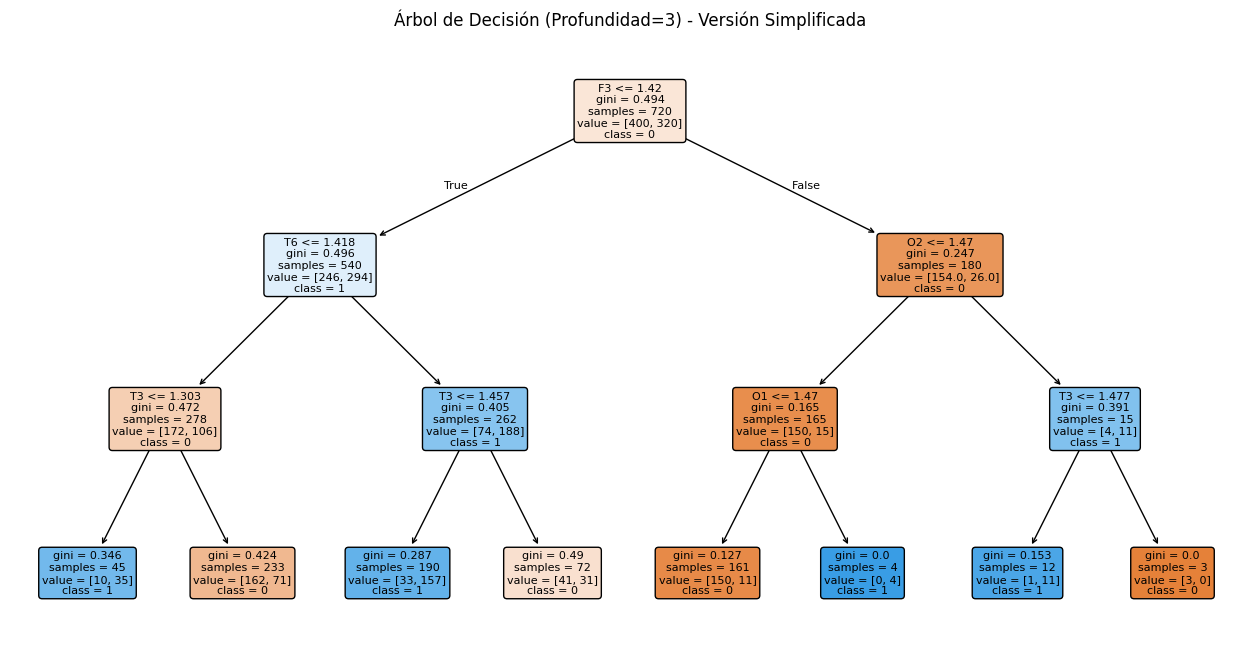

In [ ]:
# 7. Visualizar el árbol (solo si max_depth no es muy grande)
print("\n" + "="*50)
print("VISUALIZACIÓN DEL ÁRBOL")
print("="*50)

# Si el árbol no es demasiado profundo, podemos visualizarlo
if best_dt.max_depth is not None and best_dt.max_depth <= 5:
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_dt,
        feature_names=X.columns,
        class_names=[str(c) for c in label_encoder.classes_], # Convert class names to strings
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title('Árbol de Decisión Optimizado')
    plt.show()
else:
    print(f"El árbol tiene profundidad {best_dt.max_depth}, es muy grande para visualizar")
    print("Mostrando un árbol más pequeño para entender la estructura...")

    # Crear un árbol pequeño para visualizar
    dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt_small.fit(X_train, y_train)

    plt.figure(figsize=(16, 8))
    plot_tree(
        dt_small,
        feature_names=X.columns,
        class_names=[str(c) for c in label_encoder.classes_], # Convert class names to strings
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title('Árbol de Decisión (Profundidad=3) - Versión Simplificada')
    plt.show()